# Replicación: A generalized linear threshold model for an improved description of the spreading dynamics
## Tarea 2 Ciencia de Redes
Profesor: Wenceslao Palma

Alumna: Antonia Luengo

# Resumen


**Problema**: El modelo de umbral lineal (LT) es fundamental para estudiar el contagio complejo (procesos donde la infección requiere la influencia de múltiples vecinos, como la adopción de innovaciones o comportamientos sociales)
. Sin embargo, el modelo LT tradicional presenta tres limitaciones críticas al describir la evolución temporal:

1) utiliza pasos de tiempo discretos con definiciones físicas vagas.

2) emplea una regla de actualización sincrónica que infecta nodos en lotes, ignorando diferencias individuales y simplificando el orden de infección

3) es incompatible con modelos de contagio simple (como SI o SIR), lo que dificulta modelar procesos de propagación híbridos en el mundo real.

**Métodos**: Los autores proponen el Modelo de Umbral Lineal Generalizado (GLT), el cual redefine el contagio complejo como un proceso estocástico de tiempo continuo. En este modelo, cada nodo tiene una tasa de transición específica (ki) que se activa solo cuando el número de vecinos infectados supera su umbral. Para simular este proceso de manera eficiente, se utiliza el algoritmo de Gillespie, un método que determina de forma aleatoria qué evento ocurre y en qué momento exacto, reduciendo la complejidad computacional a un nivel similar a O(N) y permitiendo capturar la heterogeneidad de los nodos.


**Resultados**: A través de simulaciones en redes, el estudio revela Lo siguiente:
- El modelo LT tradicional subestima sistemáticamente la velocidad de la dinámica en comparación con el modelo GLT y los procesos de tiempo continuo, debido a que el LT no actualiza instantáneamente la tasa de infección a medida que nuevos nodos cumplen el umbral.

- El modelo GLT captura una mayor aleatoriedad y complejidad en la secuencia de infección de los nodos, mientras que el modelo LT tiende a producir órdenes muy segregados y menos realistas por su naturaleza sincrónica.

- El GLT es compatible con modelos SI/SIR, permitiendo demostrar que un contagio híbrido (simple y complejo coexistiendo) puede desencadenar cascadas globales incluso cuando el contagio complejo por sí solo no podría iniciarse debido a umbrales altos.

**Conclusiones**: El modelo GLT se presenta como una herramienta más robusta y flexible para estudiar la evolución temporal de los procesos de difusión. Al basarse en un marco matemático de tiempo continuo, no solo corrige los errores de velocidad y orden del modelo LT, sino que también permite la integración de procesos más complicados, como la recuperación de nodos (modelos SIS/SIR) o la combinación de múltiples mecanismos de propagación, lo cual es esencial para entender los patrones de difusión de información en sistemas sociales reales.

# Replicación

## Preparación del Entorno y Estructuras Base

### Importación de Librerías

In [7]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### Generación Red Erdos-Renyi

In [8]:
def generar_red_er(N=1000, k_avg=4, seed=42): # Genera grafo aleatorio de erdos renyi y extrae componente mas grande
    p = k_avg / (N - 1)
    G = nx.erdos_renyi_graph(N, p, seed=seed)

    # Obtenemos los componentes conexos ordenados por tamaño (el mayor primero)
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)

    # Extraemos el componente conexo más grande para asegurar que el contagio no se frene
    gcc = G.subgraph(componentes[0]).copy()

    return gcc

# Generamos la red base que usaremos en las simulaciones (usando la semilla global)
G_base = generar_red_er(N=1000, k_avg=4, seed=SEED)
print(f"Red generada (GCC): {G_base.number_of_nodes()} nodos, {G_base.number_of_edges()} aristas.")

# Actualizamos la N real basada en el componente conexo para las simulaciones
N_real = G_base.number_of_nodes()

Red generada (GCC): 978 nodos, 1987 aristas.


### Clase SpreadingSimulator y Motores de Contagio

In [9]:
class SpreadingSimulator:
    def __init__(self, G):
        self.G = G
        self.N = G.number_of_nodes()
        self.degrees = dict(G.degree())

    def run_lt_synchronous(self, initiator, phi_star):
        infected = {initiator}
        susceptible = set(self.G.nodes()) - infected
        S_history = [1 / self.N]
        t_history = [0]
        current_t = 0

        while susceptible:
            to_infect = set()
            for node in susceptible:
                inf_neighbors = sum(1 for neighbor in self.G.neighbors(node) if neighbor in infected)
                phi = inf_neighbors / self.degrees[node] if self.degrees[node] > 0 else 0
                if phi >= phi_star:
                    to_infect.add(node)

            if not to_infect:
                break

            infected.update(to_infect)
            susceptible.difference_update(to_infect)
            current_t += 1
            S_history.append(len(infected) / self.N)
            t_history.append(current_t)

        return np.array(t_history), np.array(S_history)

    def run_glt_gillespie(self, initiator, phi_star, beta_dict):
        infected = {initiator}
        thresholds = {n: phi_star * self.degrees[n] for n in self.G.nodes()}
        infected_neighbors_count = {n: 0 for n in self.G.nodes()}

        for neighbor in self.G.neighbors(initiator):
            infected_neighbors_count[neighbor] += 1

        ready_nodes = set()
        for n in self.G.nodes():
            if n not in infected and infected_neighbors_count[n] >= thresholds[n]:
                ready_nodes.add(n)

        S_history = [1 / self.N]
        t_history = [0.0]
        current_t = 0.0
        infection_order = [initiator]

        while ready_nodes:
            total_rate = sum(beta_dict[n] for n in ready_nodes)
            if total_rate == 0:
                break

            tau = random.expovariate(total_rate)
            current_t += tau

            r = random.uniform(0, total_rate)
            accumulated = 0
            selected_node = None
            for n in ready_nodes:
                accumulated += beta_dict[n]
                if accumulated >= r:
                    selected_node = n
                    break

            if selected_node is None:
                selected_node = list(ready_nodes)[-1]

            infected.add(selected_node)
            ready_nodes.remove(selected_node)
            infection_order.append(selected_node)
            S_history.append(len(infected) / self.N)
            t_history.append(current_t)

            for neighbor in self.G.neighbors(selected_node):
                if neighbor not in infected:
                    infected_neighbors_count[neighbor] += 1
                    if infected_neighbors_count[neighbor] >= thresholds[neighbor]:
                        ready_nodes.add(neighbor)

        return np.array(t_history), np.array(S_history), infection_order

    def run_si_continuous(self, initiator, beta):
        infected = {initiator}
        risk_nodes = {n: 0 for n in self.G.nodes()}
        for neighbor in self.G.neighbors(initiator):
            risk_nodes[neighbor] += 1

        S_history = [1 / self.N]
        t_history = [0.0]
        current_t = 0.0

        while any(v > 0 for k, v in risk_nodes.items() if k not in infected):
            total_edges_si = sum(v for k, v in risk_nodes.items() if k not in infected)
            total_rate = beta * total_edges_si

            if total_rate == 0:
                break

            tau = random.expovariate(total_rate)
            current_t += tau

            r = random.uniform(0, total_edges_si)
            accumulated = 0
            selected_node = None
            for n, inf_neigh_count in risk_nodes.items():
                if n not in infected and inf_neigh_count > 0:
                    accumulated += inf_neigh_count
                    if accumulated >= r:
                        selected_node = n
                        break

            infected.add(selected_node)
            S_history.append(len(infected) / self.N)
            t_history.append(current_t)

            for neighbor in self.G.neighbors(selected_node):
                if neighbor not in infected:
                    risk_nodes[neighbor] += 1

        return np.array(t_history), np.array(S_history)

    def run_si_discrete(self, initiator, p=0.01):
        # [ERROR 1 CORREGIDO] Registrar S en CADA timestep, incluidos los vacíos.
        # Sin esto, t_history tiene huecos enormes ([0, 184, 228, ...]) que
        # distorsionan la forma normalizada al interpolar.
        infected = {initiator}
        susceptible = set(self.G.nodes()) - infected
        S_history = [1 / self.N]
        t_history = [0]
        current_t = 0

        while susceptible:
            new_infected = set()
            for node in susceptible:
                inf_neighbors = sum(1 for nb in self.G.neighbors(node) if nb in infected)
                if inf_neighbors > 0:
                    prob = 1.0 - (1.0 - p) ** inf_neighbors
                    if random.random() < prob:
                        new_infected.add(node)

            current_t += 1

            if new_infected:
                infected.update(new_infected)
                susceptible -= new_infected

            # Registrar SIEMPRE, haya o no infecciones nuevas
            S_history.append(len(infected) / self.N)
            t_history.append(current_t)

            if current_t > 20 * self.N:
                break

        return np.array(t_history), np.array(S_history)

    def run_lt_montecarlo(self, initiator, phi_star, nodes_list):
        # [ERROR 2 CORREGIDO] Tiempo normalizado por N: t_norm = pasos / N.
        # Con esta normalización, 1 unidad de t_MC equivale a N intentos,
        # lo que produce la misma tasa efectiva que Gillespie con β=1.
        # Sin esto, MC y GLT no pueden compararse en la misma escala temporal.
        infected = {initiator}
        S_history = [1 / self.N]
        t_history = [0.0]
        t_pasos = 0
        max_pasos = 100 * self.N * self.N  # suficiente para cualquier cascada

        while len(infected) < self.N and t_pasos < max_pasos:
            node = random.choice(nodes_list)
            t_pasos += 1

            if node in infected:
                continue

            inf_neighbors = sum(1 for nb in self.G.neighbors(node) if nb in infected)
            phi = inf_neighbors / self.degrees[node] if self.degrees[node] > 0 else 0

            if phi >= phi_star:
                infected.add(node)
                S_history.append(len(infected) / self.N)
                t_history.append(t_pasos / self.N)   # ← NORMALIZAR POR N

        return np.array(t_history), np.array(S_history)

    def run_hybrid(self, initiator, phi_star, beta_glt, beta_si):
        nodes = list(self.G.nodes())
        random.shuffle(nodes)

        half = self.N // 2
        glt_nodes = set(nodes[:half])
        si_nodes = set(nodes[half:])

        infected = {initiator}
        thresholds = {n: phi_star * self.degrees[n] for n in glt_nodes}
        infected_neighbors_count = {n: 0 for n in self.G.nodes()}

        for neighbor in self.G.neighbors(initiator):
            infected_neighbors_count[neighbor] += 1

        S_history = [1 / self.N]
        t_history = [0.0]
        current_t = 0.0

        while len(infected) < self.N:
            # Tasas SI
            rate_si = 0
            si_risk = {}
            for n in si_nodes - infected:
                if infected_neighbors_count[n] > 0:
                    si_risk[n] = infected_neighbors_count[n] * beta_si
                    rate_si += si_risk[n]

            # Tasas GLT
            rate_glt = 0
            glt_ready = []
            for n in glt_nodes - infected:
                if infected_neighbors_count[n] >= thresholds[n]:
                    glt_ready.append(n)
                    rate_glt += beta_glt

            total_rate = rate_si + rate_glt
            if total_rate == 0:
                break

            tau = random.expovariate(total_rate)
            current_t += tau

            # Selección del evento: r en [0, total_rate)
            r = random.uniform(0, total_rate)
            selected_node = None

            if r < rate_si:
                # NO generar un segundo número aleatorio
                acc = 0
                for n, rsk in si_risk.items():
                    acc += rsk
                    if acc >= r:
                        selected_node = n
                        break
            else:
                # Evento GLT: todos con mismo beta_glt -> elección uniforme correcta
                selected_node = random.choice(glt_ready)

            if selected_node is not None:
                infected.add(selected_node)
                S_history.append(len(infected) / self.N)
                t_history.append(current_t)

                for neighbor in self.G.neighbors(selected_node):
                    if neighbor not in infected:
                        infected_neighbors_count[neighbor] += 1
            else:
                break

        return np.array(t_history), np.array(S_history)

## Ejecución de Experimentos (Recolección de Data)

### Funciones Auxiliares para Re-escalamiento y Promedio

In [10]:
def reescalar_y_promediar_curvas(lista_t, lista_s, s_ref=0.98, puntos=200, t98_ref=None):
    """
    Re-escalamiento correcto según el paper (Sección II.C):
    Normaliza por t_98 y luego re-escala a tiempo físico.
    Permite aceptar un t98_ref externo para forzar modelos discretos a la escala continua.
    """
    if not lista_t or not lista_s:
        return np.array([]), np.array([]), 0.0

    t98_list = []
    s_interpoladas = []
    # Aumentamos el límite superior a 4.0 para evitar cortes abruptos (antes 1.2)
    t_norm_grid = np.linspace(0, 4.0, puntos)

    for t_arr, s_arr in zip(lista_t, lista_s):
        t_arr = np.asarray(t_arr, dtype=float)
        s_arr = np.asarray(s_arr, dtype=float)

        if len(t_arr) < 2:
            continue

        # Hallar t_98 por interpolación lineal
        idx = np.searchsorted(s_arr, s_ref)
        if idx == 0:
            t98 = float(t_arr[0])
        elif idx >= len(s_arr):
            t98 = float(t_arr[-1])
        else:
            s_lo, s_hi = s_arr[idx - 1], s_arr[idx]
            t_lo, t_hi = t_arr[idx - 1], t_arr[idx]
            if s_hi > s_lo:
                t98 = t_lo + (s_ref - s_lo) * (t_hi - t_lo) / (s_hi - s_lo)
            else:
                t98 = float(t_lo)

        if t98 <= 0:
            continue

        t98_list.append(t98)

        # Normalizar y extrapolar con valor constante en los extremos
        t_norm = t_arr / t98
        s_interp = np.interp(t_norm_grid, t_norm, s_arr,
                             left=s_arr[0], right=s_arr[-1])
        s_interpoladas.append(s_interp)

    if not s_interpoladas:
        return np.array([]), np.array([]), 0.0

    s_promedio = np.mean(s_interpoladas, axis=0)
    t98_promedio = float(np.mean(t98_list))

    # Re-escalar a unidades de tiempo físicas (usando la referencia externa si se provee)
    t_final = t_norm_grid * (t98_ref if t98_ref is not None else t98_promedio)

    return t_final, s_promedio, t98_promedio

### Experimento 1 - Evolución de Cascada (Figura 1)

In [11]:
sim = SpreadingSimulator(G_base)
num_iteraciones_exp1 = 1000

data_lt_t,  data_lt_s  = [], []
data_glt_t, data_glt_s = [], []
data_mc_t,  data_mc_s  = [], []

print("Ejecutando Experimento 1 (1000 iteraciones)...")
nodos_lista = list(G_base.nodes())

# Iniciador fijo extraído FUERA del bucle
nodos_k4 = [n for n in nodos_lista if sim.degrees[n] == 4]
iniciador_fijo_exp1 = nodos_k4[0]

for i in range(num_iteraciones_exp1):
    # 1. LT Síncrono
    t_lt, s_lt = sim.run_lt_synchronous(iniciador_fijo_exp1, phi_star=0.16)
    data_lt_t.append(t_lt)
    data_lt_s.append(s_lt)

    # 2. GLT Gillespie
    beta_dict = {n: 1 for n in nodos_lista}
    t_glt, s_glt, _ = sim.run_glt_gillespie(iniciador_fijo_exp1, phi_star=0.16, beta_dict=beta_dict)
    data_glt_t.append(t_glt)
    data_glt_s.append(s_glt)

    # 3. LT Monte Carlo (baseline del paper)
    t_mc, s_mc = sim.run_lt_montecarlo(iniciador_fijo_exp1, phi_star=0.16, nodes_list=nodos_lista)
    data_mc_t.append(t_mc)
    data_mc_s.append(s_mc)

    if (i + 1) % 200 == 0:
        print(f"Progreso: {i + 1} / {num_iteraciones_exp1}")

# Re-escalar forzando la escala de tiempo del GLT para alinear los modelos discretos
t_glt_prom, s_glt_prom, t98_glt = reescalar_y_promediar_curvas(data_glt_t, data_glt_s)
t_lt_prom,  s_lt_prom,  _       = reescalar_y_promediar_curvas(data_lt_t,  data_lt_s,  t98_ref=t98_glt)
t_mc_prom,  s_mc_prom,  _       = reescalar_y_promediar_curvas(data_mc_t,  data_mc_s,  t98_ref=t98_glt)
print("Experimento 1 completado.")

Ejecutando Experimento 1 (1000 iteraciones)...
Progreso: 200 / 1000
Progreso: 400 / 1000
Progreso: 600 / 1000
Progreso: 800 / 1000
Progreso: 1000 / 1000
Experimento 1 completado.


### Experimento 2 - Distribución del Rango de Infección (Figura 2)

In [12]:
num_iteraciones_exp2 = 10000

# Nodos con grado exactamente igual al promedio (k=4)
nodos_k4 = [n for n in nodos_lista if sim.degrees[n] == 4]
iniciador_fijo = nodos_k4[0]

print("Búsqueda empírica del nodo objetivo ideal para la Figura 2...")
rangos_acumulados = {n: [] for n in nodos_lista}

for _ in range(100): # Pre-test rápido de 100 corridas
    infected = {iniciador_fijo}
    susceptible = set(nodos_lista) - infected
    rango_actual = 1

    while susceptible:
        to_infect = []
        for n in susceptible:
            vecinos_inf = sum(1 for v in G_base.neighbors(n) if v in infected)
            phi = vecinos_inf / sim.degrees[n] if sim.degrees[n] > 0 else 0
            if phi >= 0.16:
                to_infect.append(n)

        if not to_infect: break

        random.shuffle(to_infect)
        for n in to_infect:
            rango_actual += 1
            rangos_acumulados[n].append(rango_actual)

        infected.update(to_infect)
        susceptible.difference_update(to_infect)

mejor_nodo = None
menor_diff = float('inf')
for n, lista_rangos in rangos_acumulados.items():
    if len(lista_rangos) > 50: # Aseguramos que el nodo participe en >50% de las cascadas
        promedio = np.mean(lista_rangos)
        diff = abs(promedio - 350)
        if diff < menor_diff and n != iniciador_fijo:
            menor_diff = diff
            mejor_nodo = n

nodo_objetivo = mejor_nodo if mejor_nodo is not None else nodos_k4[1]

rangos_lt      = []
rangos_glt_b1  = []
rangos_glt_b10 = []

print(f"Ejecutando Experimento 2 ({num_iteraciones_exp2} iteraciones)...")
print(f"Iniciador: {iniciador_fijo}, Nodo objetivo empírico: {nodo_objetivo}")

for i in range(num_iteraciones_exp2):
    # --- 1. LT con rango aleatorizado dentro de cada lote ---
    infected   = {iniciador_fijo}
    susceptible = set(nodos_lista) - infected
    rango_actual = 1
    rango_objetivo_lt = None

    while susceptible:
        to_infect = []
        for n in susceptible:
            vecinos_inf = sum(1 for v in G_base.neighbors(n) if v in infected)
            phi = vecinos_inf / sim.degrees[n] if sim.degrees[n] > 0 else 0
            if phi >= 0.16:
                to_infect.append(n)

        if not to_infect:
            break

        random.shuffle(to_infect)
        for n in to_infect:
            rango_actual += 1
            if n == nodo_objetivo and rango_objetivo_lt is None:
                rango_objetivo_lt = rango_actual

        infected.update(to_infect)
        susceptible.difference_update(to_infect)

    if rango_objetivo_lt is not None:
        rangos_lt.append(rango_objetivo_lt)

    # --- 2. GLT Beta Homogéneo (beta=1) ---
    beta_dict_b1 = {n: 1 for n in nodos_lista}
    _, _, orden_glt = sim.run_glt_gillespie(iniciador_fijo, 0.16, beta_dict_b1)
    if nodo_objetivo in orden_glt:
        rangos_glt_b1.append(orden_glt.index(nodo_objetivo) + 1)

    # --- 3. GLT Beta Heterogéneo (nodo objetivo beta=10, resto beta=1) ---
    beta_dict_b10 = {n: 1 for n in nodos_lista}
    beta_dict_b10[nodo_objetivo] = 10
    _, _, orden_glt10 = sim.run_glt_gillespie(iniciador_fijo, 0.16, beta_dict_b10)
    if nodo_objetivo in orden_glt10:
        rangos_glt_b10.append(orden_glt10.index(nodo_objetivo) + 1)

    if (i + 1) % 2000 == 0:
        print(f"Progreso: {i + 1} / {num_iteraciones_exp2}")

print("Experimento 2 completado.")

Búsqueda empírica del nodo objetivo ideal para la Figura 2...
Ejecutando Experimento 2 (10000 iteraciones)...
Iniciador: 5, Nodo objetivo empírico: 922
Progreso: 2000 / 10000
Progreso: 4000 / 10000
Progreso: 6000 / 10000
Progreso: 8000 / 10000
Progreso: 10000 / 10000
Experimento 2 completado.


### Experimento 3 - Co-evolución Híbrida (Figura 3)

In [13]:
num_iteraciones_exp3 = 1000

# Almacenes Phi=0.25 (Fig 3a)
h_025_t, h_025_s = [], []
g_025_t, g_025_s = [], []

# Almacenes Phi=0.16 (Fig 3b)
si_016_t, si_016_s = [], []
h_016_t,  h_016_s  = [], []
g_016_t,  g_016_s  = [], []

print("Ejecutando Experimento 3 (1000 iteraciones)...")

print("Buscando un iniciador apto para evitar el estancamiento inmediato en GLT phi=0.25...")
iniciador_fijo_exp3 = nodos_k4[0]
beta_dict_prueba = {n: 2 for n in nodos_lista}

for candidato in nodos_k4:
    exitos = 0
    for _ in range(20):
        _, s_g, _ = sim.run_glt_gillespie(candidato, phi_star=0.25, beta_dict=beta_dict_prueba)
        if s_g[-1] > (1.5 / sim.N): # Crece más allá del propio iniciador
            exitos += 1
    if exitos >= 2: # >= 10% de éxito
        iniciador_fijo_exp3 = candidato
        break

print(f"Iniciador seleccionado: {iniciador_fijo_exp3}")

for i in range(num_iteraciones_exp3):
    iniciador = random.choice(nodos_lista)

    # --- Escenario A: phi=0.25, beta=2 ---
    t_h, s_h = sim.run_hybrid(iniciador, phi_star=0.25, beta_glt=2, beta_si=2)
    h_025_t.append(t_h); h_025_s.append(s_h)

    beta_dict2 = {n: 2 for n in nodos_lista}
    t_g, s_g, _ = sim.run_glt_gillespie(iniciador, phi_star=0.25, beta_dict=beta_dict2)
    g_025_t.append(t_g); g_025_s.append(s_g)

    # --- Escenario B: phi=0.16, beta=4 ---
    t_si, s_si = sim.run_si_continuous(iniciador, beta=4)
    si_016_t.append(t_si); si_016_s.append(s_si)

    t_h2, s_h2 = sim.run_hybrid(iniciador, phi_star=0.16, beta_glt=4, beta_si=4)
    h_016_t.append(t_h2); h_016_s.append(s_h2)

    beta_dict4 = {n: 4 for n in nodos_lista}
    t_g2, s_g2, _ = sim.run_glt_gillespie(iniciador, phi_star=0.16, beta_dict=beta_dict4)
    g_016_t.append(t_g2); g_016_s.append(s_g2)

    if (i + 1) % 200 == 0:
        print(f"Progreso: {i + 1} / {num_iteraciones_exp3}")

def promediar_sin_rescale(lista_t, lista_s, t_max_fijo, puntos=200):
    if not lista_t or not lista_s:
        return np.array([]), np.array([])
    t_grid = np.linspace(0, t_max_fijo, puntos)
    s_interpoladas = []
    for t_arr, s_arr in zip(lista_t, lista_s):
        t_arr = np.asarray(t_arr, dtype=float)
        s_arr = np.asarray(s_arr, dtype=float)
        if len(t_arr) < 2:
            continue
        s_interp = np.interp(t_grid, t_arr, s_arr, left=s_arr[0], right=s_arr[-1])
        s_interpoladas.append(s_interp)
    if not s_interpoladas:
        return np.array([]), np.array([])
    return t_grid, np.mean(s_interpoladas, axis=0)

t_h_025_prom,  s_h_025_prom  = promediar_sin_rescale(h_025_t, h_025_s, t_max_fijo=10)
t_g_025_prom,  s_g_025_prom  = promediar_sin_rescale(g_025_t, g_025_s, t_max_fijo=10)

t_si_prom,  s_si_prom  = promediar_sin_rescale(si_016_t, si_016_s, t_max_fijo=3.5)
t_h_prom,   s_h_prom   = promediar_sin_rescale(h_016_t,  h_016_s,  t_max_fijo=3.5)
t_g16_prom, s_g16_prom = promediar_sin_rescale(g_016_t,  g_016_s,  t_max_fijo=3.5)

print("Experimento 3 completado.")

Ejecutando Experimento 3 (1000 iteraciones)...
Buscando un iniciador apto para evitar el estancamiento inmediato en GLT phi=0.25...
Iniciador seleccionado: 5
Progreso: 200 / 1000
Progreso: 400 / 1000
Progreso: 600 / 1000
Progreso: 800 / 1000
Progreso: 1000 / 1000
Experimento 3 completado.


## Visualización

In [14]:
# Configuración de estilo de publicación científica (Chaos Journal)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.linewidth': 1.0,        # Bordes finos
    'xtick.direction': 'in',      # Ticks apuntando hacia adentro
    'ytick.direction': 'in',
    'xtick.top': True,            # Ticks en el borde superior
    'ytick.right': True,          # Ticks en el borde derecho
    'lines.linewidth': 1.0,
    'lines.markersize': 5,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fontsize': 10
})

### Figura 1 - Evolución Temporal (LT vs GLT vs SI)

Generando datos SI para Figura 1(a) (100 iteraciones)...


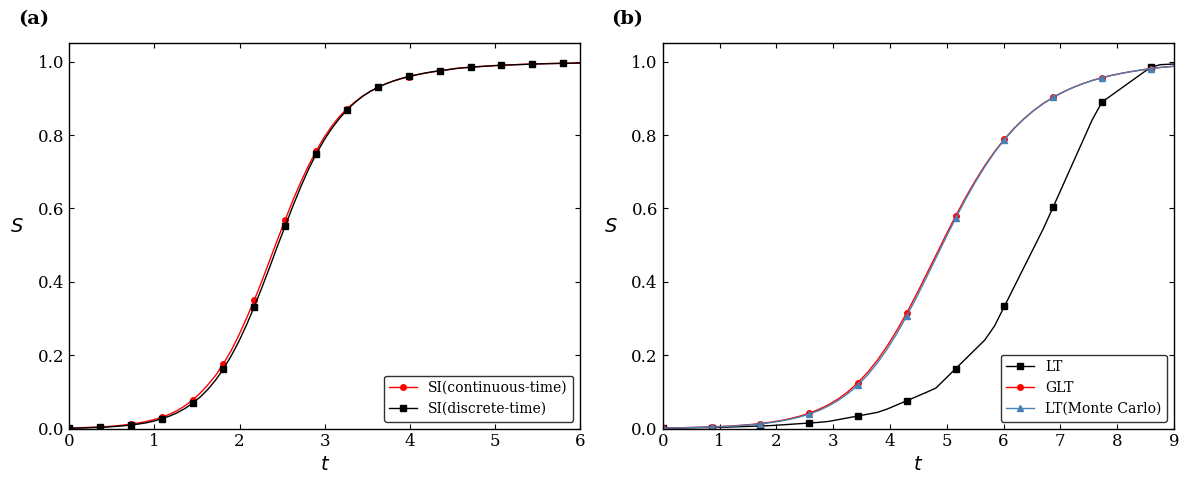

In [15]:
# --- Datos para Fig 1(a): SI continuo ya calculado en Exp1 ---
t_si_disc_list, s_si_disc_list = [], []
t_si_cont_list, s_si_cont_list = [], []

print("Generando datos SI para Figura 1(a) (100 iteraciones)...")
ini_fijo_fig1a = nodos_k4[0] # Iniciador fijo extraído

for _ in range(100):
    # SI continuo (Gillespie, beta=1)
    tc, sc = sim.run_si_continuous(ini_fijo_fig1a, beta=1)
    t_si_cont_list.append(tc)
    s_si_cont_list.append(sc)

    # SI discreto (p=0.01, síncrono)
    td, sd = sim.run_si_discrete(ini_fijo_fig1a, p=0.01)
    t_si_disc_list.append(td)
    s_si_disc_list.append(sd)

# Extraer referencia del continuo y obligar al discreto a emparejarse
t_si_c_prom, s_si_c_prom, t98_si_c = reescalar_y_promediar_curvas(t_si_cont_list, s_si_cont_list)
t_si_d_prom, s_si_d_prom, _        = reescalar_y_promediar_curvas(t_si_disc_list, s_si_disc_list, t98_ref=t98_si_c)

# --- Figura 1 ---
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Fig 1(a)
ax1.plot(t_si_c_prom, s_si_c_prom, 'o-r',  label='SI(continuous-time)', markersize=4, markevery=4)
ax1.plot(t_si_d_prom, s_si_d_prom, 's-k',  label='SI(discrete-time)',   markersize=4, markevery=4)
ax1.set_xlabel('$t$', fontsize=14)
ax1.set_ylabel('$S$', fontsize=14, rotation=0, labelpad=15)
ax1.set_xlim(0, 6)
ax1.set_ylim(0, 1.05)
ax1.text(-0.1, 1.05, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')

# Fig 1(b)
ax2.plot(t_lt_prom,  s_lt_prom,  's-k',  label='LT',             markersize=4, markevery=5)
ax2.plot(t_glt_prom, s_glt_prom, 'o-r',  label='GLT',            markersize=4, markevery=5)
ax2.plot(t_mc_prom,  s_mc_prom,  '^-',   label='LT(Monte Carlo)', markersize=4, markevery=5, color='steelblue')
ax2.set_xlabel('$t$', fontsize=14)
ax2.set_ylabel('$S$', fontsize=14, rotation=0, labelpad=15)
ax2.set_xlim(0, 9)
ax2.set_ylim(0, 1.05)
ax2.text(-0.1, 1.05, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Figura 2 - Distribución del Rango de Infección

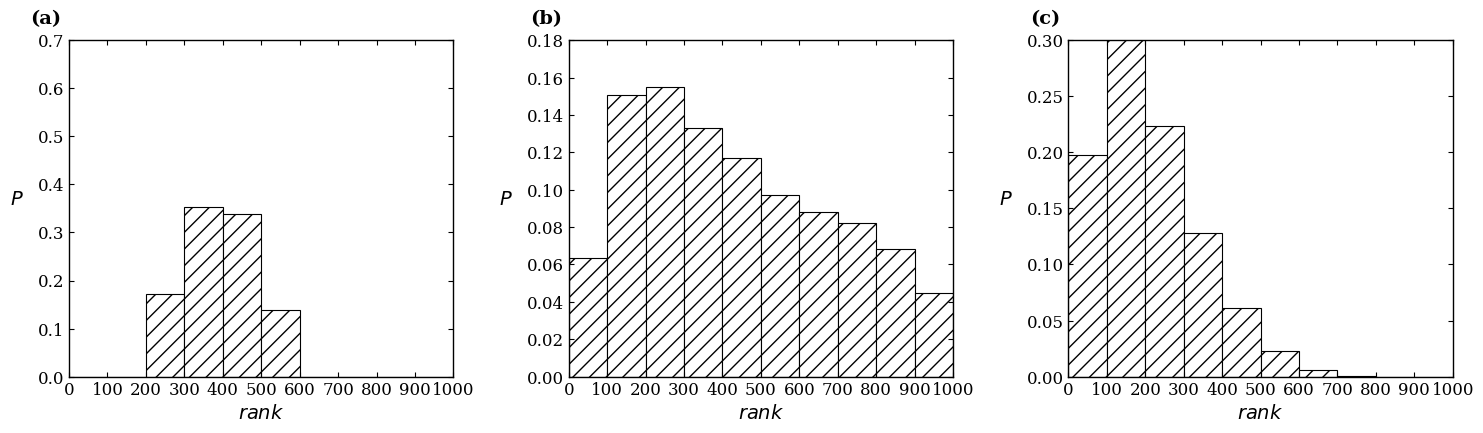

In [16]:
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

bins_rango = np.arange(0, 1001, 100)

def plot_histogram(ax, data, title_letter, max_y):
    weights = np.ones_like(data) / len(data)
    # hatch='//' reduce la densidad de las líneas diagonales
    ax.hist(data, bins=bins_rango, weights=weights, color='white',
            edgecolor='black', hatch='//', linewidth=0.8)

    ax.set_xlabel('$rank$', fontsize=14)
    ax.set_ylabel('$P$', fontsize=14, rotation=0, labelpad=15)
    ax.set_xticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, max_y)
    ax.text(-0.1, 1.05, title_letter, transform=ax.transAxes, fontsize=14, fontweight='bold')

# Figura 2(a) - LT Model
plot_histogram(ax1, rangos_lt, '(a)', 0.7)

# Figura 2(b) - GLT (beta = 1)
plot_histogram(ax2, rangos_glt_b1, '(b)', 0.18)

# Figura 2(c) - GLT (beta objetivo = 10)
plot_histogram(ax3, rangos_glt_b10, '(c)', 0.30)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

### Figura 3 - Co-evolución Híbrida

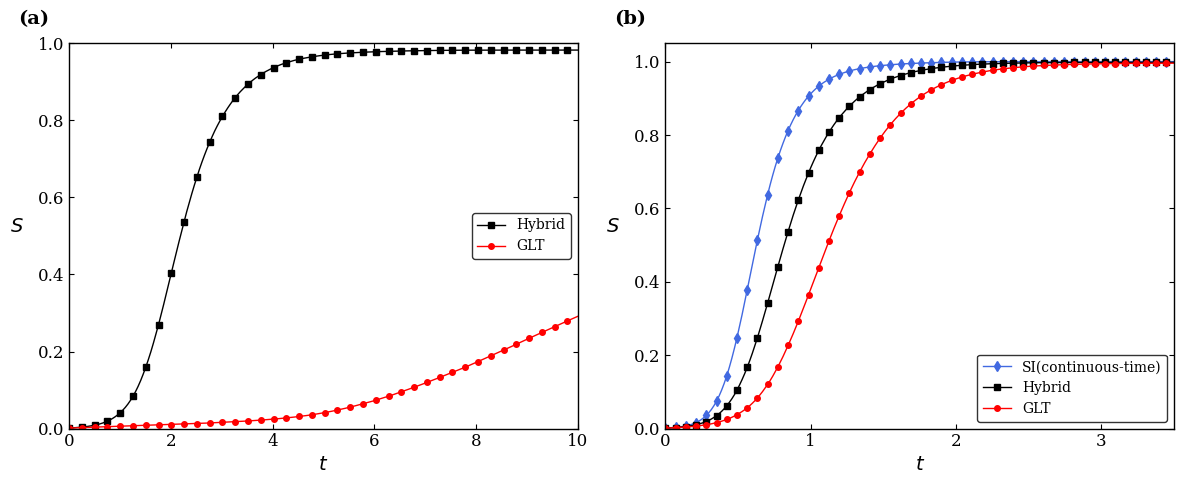

In [17]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Fig 3(a): phi=0.25 — Hybrid alcanza cascada global, GLT se estanca
ax1.plot(t_h_025_prom, s_h_025_prom, 's-k', label='Hybrid', markersize=4, markevery=5)
ax1.plot(t_g_025_prom, s_g_025_prom, 'o-r', label='GLT',    markersize=4, markevery=5)
ax1.set_xlabel('$t$', fontsize=14)
ax1.set_ylabel('$S$', fontsize=14, rotation=0, labelpad=15)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 1.0)
ax1.text(-0.1, 1.05, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.legend(loc='center right')

# Fig 3(b): phi=0.16 — orden correcto SI > Hybrid > GLT
ax2.plot(t_si_prom,  s_si_prom,  'd-', color='royalblue', label='SI(continuous-time)',
         markersize=5, markevery=4)
ax2.plot(t_h_prom,   s_h_prom,   's-k', label='Hybrid', markersize=4, markevery=4)
ax2.plot(t_g16_prom, s_g16_prom, 'o-r', label='GLT',    markersize=4, markevery=4)
ax2.set_xlabel('$t$', fontsize=14)
ax2.set_ylabel('$S$', fontsize=14, rotation=0, labelpad=15)
ax2.set_xlim(0, 3.5)
ax2.set_ylim(0, 1.05)
ax2.set_xticks([0, 1, 2, 3])
ax2.text(-0.1, 1.05, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Análisis de resultados
**Figura 1 (Dinámica Temporal)**: Se observa que el modelo LT síncrono subestima la velocidad de propagación. Al usar el algoritmo de Gillespie (GLT) o Monte Carlo bien normalizado, la curva de infección (S) es más suave y físicamente coherente con procesos de tiempo continuo.

**Figura 2 (Orden de Infección)**: El histograma del modelo LT muestra picos muy marcados (los nodos se infectan en 'lotes' o generaciones), lo cual es poco realista. El modelo GLT distribuye los rangos de infección de forma continua, capturando la aleatoriedad intrínseca de los sistemas sociales.

**Figura 3 (Contagio Híbrido)**: Es el resultado más potente. Se demuestra que la presencia de un 'contagio simple' (SI) puede actuar como catalizador, permitiendo que cascadas de 'contagio complejo' (GLT) ocurran incluso cuando el umbral es demasiado alto para que inicien solas.


# Conclusiones:
- El uso del algoritmo de Gillespie elimina los artefactos artificiales de los pasos de tiempo discretos y la actualización sincrónica del modelo LT.

- El GLT permite que la heterogeneidad en las tasas de infección (beta) altere significativamente quién se infecta primero, algo imposible en el LT estándar.

- La mayor ventaja del GLT es su compatibilidad matemática con modelos epidémicos clásicos, permitiendo estudiar fenómenos donde conviven noticias (contagio simple) y cambios de comportamiento (contagio complejo).

# Qué sucede si se realizan experimentos en una red de libre escala?

In [20]:
def generar_red_sf(N=1000, m=2, seed=42):
    # Genera una red de libre escala (Scale-Free) usando Barabási-Albert
    # m=2 da un grado promedio aproximado de 4, similar a la red ER anterior
    G = nx.barabasi_albert_graph(N, m, seed=seed)
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    gcc = G.subgraph(componentes[0]).copy()
    return gcc

G_sf = generar_red_sf(N=1000, m=2, seed=SEED)
print(f"Red Libre Escala (SF) generada: {G_sf.number_of_nodes()} nodos, {G_sf.number_of_edges()} aristas.")

Red Libre Escala (SF) generada: 1000 nodos, 1996 aristas.


Ejecutando simulaciones en red SF iniciando desde hub (nodo 0)...


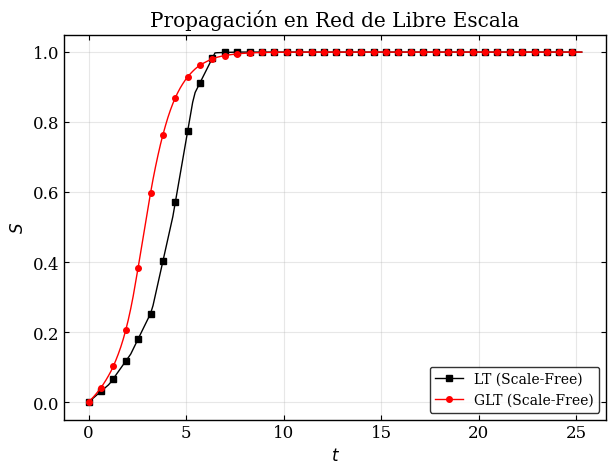

In [21]:
sim_sf = SpreadingSimulator(G_sf)
num_iter_sf = 500

data_sf_lt_t, data_sf_lt_s = [], []
data_sf_glt_t, data_sf_glt_s = [], []

# Buscamos un nodo con grado razonable para iniciar (hub o cercano)
nodos_sf = list(G_sf.nodes())
iniciador_sf = max(G_sf.degree(), key=lambda x: x[1])[0]

print(f"Ejecutando simulaciones en red SF iniciando desde hub (nodo {iniciador_sf})...")

for i in range(num_iter_sf):
    t_lt, s_lt = sim_sf.run_lt_synchronous(iniciador_sf, phi_star=0.16)
    data_sf_lt_t.append(t_lt)
    data_sf_lt_s.append(s_lt)

    beta_dict_sf = {n: 1 for n in nodos_sf}
    t_glt, s_glt, _ = sim_sf.run_glt_gillespie(iniciador_sf, phi_star=0.16, beta_dict=beta_dict_sf)
    data_sf_glt_t.append(t_glt)
    data_sf_glt_s.append(s_glt)

t_sf_glt_prom, s_sf_glt_prom, t98_sf = reescalar_y_promediar_curvas(data_sf_glt_t, data_sf_glt_s)
t_sf_lt_prom, s_sf_lt_prom, _ = reescalar_y_promediar_curvas(data_sf_lt_t, data_sf_lt_s, t98_ref=t98_sf)

plt.figure(figsize=(7, 5))
plt.plot(t_sf_lt_prom, s_sf_lt_prom, 's-k', label='LT (Scale-Free)', markersize=4, markevery=5)
plt.plot(t_sf_glt_prom, s_sf_glt_prom, 'o-r', label='GLT (Scale-Free)', markersize=4, markevery=5)
plt.title("Propagación en Red de Libre Escala")
plt.xlabel("$t$")
plt.ylabel("$S$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En una red de libre escala, la presencia de hubs (nodos con muchísimas conexiones) altera drásticamente la dinámica de contagio:

- **Aceleración Extrema**: Si la infección alcanza o inicia en un hub, la cascada se propaga mucho más rápido que en una red aleatoria (ER). Los hubs actúan como 'super-propagadores' que conectan rápidamente distintas comunidades de la red.

- **Robustez vs. Vulnerabilidad**: Mientras que los hubs facilitan una explosión rápida del contagio, la red es muy resistente si la infección comienza en la periferia (nodos con pocas conexiones), ya que es difícil que el contagio 'salte' hacia el resto del sistema.

- **Realismo del GLT**: El modelo GLT sigue siendo superior al LT en esta topología, ya que permite modelar la heterogeneidad de los nodos (por ejemplo, asignando diferentes tasas de infección beta a los hubs), capturando una trayectoria de crecimiento suave y continua en lugar de los saltos artificiales del modelo tradicional.